# ModelGrid: Systematic Parameter Sweeps

`ModelGrid` trains an entire grid of ToyModels in parallel using
`torch.vmap`, making parameter sweeps dramatically faster than
sequential training. This example covers:

1. **1D sweep** -- superposition vs. feature sparsity
2. **Visualizing feature norms** across the sweep
3. **2D sweep** -- phase diagram over sparsity and importance decay
4. **Snapshot training dynamics** -- watching superposition emerge

In [1]:
import torch
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from occhio import ToyModel, ModelGrid
from occhio.autoencoders import TiedLinearRelu
from occhio.distributions import SparseUniform
from occhio.model_grid import Axis

pio.renderers.default = "png"

In [2]:
# Shared experiment parameters. 50 features compressed into 15 hidden
# dimensions gives a 3.3x compression ratio -- enough to force
# meaningful superposition trade-offs.
N_FEATURES = 50
N_HIDDEN = 15
N_EPOCHS = 25000
LEARNING_RATE = 3e-4
BATCH_SIZE = 1024
SEED = 42
DEVICE = "cpu"

---
## Part 1: 1D Sweep -- Superposition vs. Feature Sparsity

How does the degree of superposition change as features become more
or less sparse? We sweep `p_active` from 0.001 (extremely sparse)
to 0.1 (moderately dense) and train all five models simultaneously.

In [3]:
# ModelGrid requires a factory function that receives a `params` dict
# and returns a ToyModel. Every model must share the same autoencoder
# class and shape (a vmap constraint), but distributions can vary.


def create_model(params):
    """Factory: build a SparseUniform ToyModel for a given p_active."""
    p_active = params["p_active"]
    gen = torch.Generator(DEVICE).manual_seed(SEED)
    return ToyModel(
        distribution=SparseUniform(
            N_FEATURES, p_active=p_active, device=DEVICE, generator=gen
        ),
        ae=TiedLinearRelu(N_FEATURES, N_HIDDEN, generator=gen, device=DEVICE),
        device=DEVICE,
    )

In [4]:
p_active_values = [0.001, 0.005, 0.01, 0.05, 0.1]

grid_1d = ModelGrid(
    create_model=create_model,
    axes=[Axis("p_active", p_active_values)],
)

print(f"Grid shape: {grid_1d.shape}")
print(f"Total models: {grid_1d.models.size}")
print(f"Architecture: {N_FEATURES} features -> {N_HIDDEN} hidden dims")

Grid shape: (5,)
Total models: 5
Architecture: 50 features -> 15 hidden dims


In [5]:
# fit() trains all models in one vectorized pass. With vmap, this is
# typically 3-10x faster than looping over models sequentially.
grid_1d.fit(
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=True,
)

  0%|          | 0/25000 [00:00<?, ?epoch/s]

In [6]:
# Extract per-model metrics from the trained grid.
superposition_values = []
mean_norm_values = []

for i, p in enumerate(p_active_values):
    model = grid_1d[i]
    sup = model.superposition.item()
    norm = model.feature_norms.mean().item()
    superposition_values.append(sup)
    mean_norm_values.append(norm)
    print(f"p_active={p:.3f}  superposition={sup:.4f}  mean_norm={norm:.4f}")

p_active=0.001  superposition=0.5695  mean_norm=1.0954
p_active=0.005  superposition=0.5555  mean_norm=1.1038
p_active=0.010  superposition=0.5551  mean_norm=1.1121
p_active=0.050  superposition=0.5643  mean_norm=1.1130
p_active=0.100  superposition=0.6108  mean_norm=1.0690


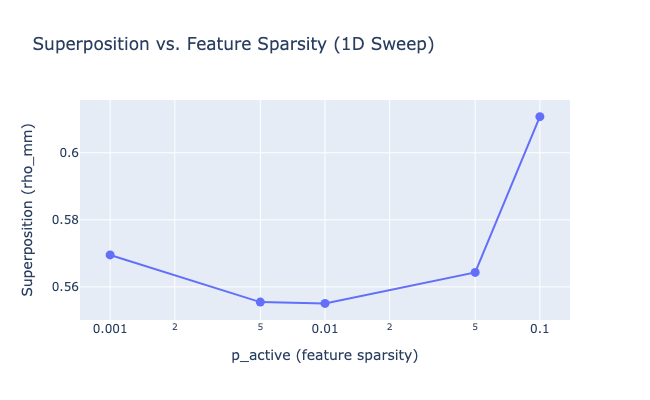

In [7]:
fig_sup = go.Figure()
fig_sup.add_trace(
    go.Scatter(
        x=p_active_values,
        y=superposition_values,
        mode="lines+markers",
        marker=dict(size=9),
        line=dict(width=2),
    )
)
fig_sup.update_xaxes(type="log", title_text="p_active (feature sparsity)")
fig_sup.update_yaxes(title_text="Superposition (rho_mm)")
fig_sup.update_layout(
    title="Superposition vs. Feature Sparsity (1D Sweep)",
    height=400,
    width=650,
)
fig_sup.show()

---
## Part 2: Feature Norms Across the Sweep

Feature norms reveal which features the network has chosen to
represent strongly vs. which it has dropped. At high sparsity the
network can represent nearly all features; as density increases it
must sacrifice some.

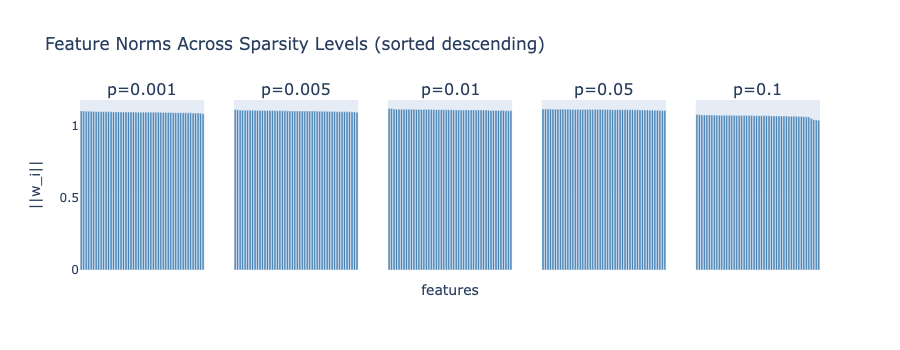

In [8]:
fig_norms = make_subplots(
    rows=1,
    cols=len(p_active_values),
    subplot_titles=[f"p={p}" for p in p_active_values],
    shared_yaxes=True,
)

for i, p in enumerate(p_active_values):
    model = grid_1d[i]
    norms = model.feature_norms.numpy()
    # Sort descending for a clean waterfall view
    norms_sorted = np.sort(norms)[::-1]
    fig_norms.add_trace(
        go.Bar(
            x=list(range(N_FEATURES)),
            y=norms_sorted,
            marker_color="steelblue",
            showlegend=False,
        ),
        row=1,
        col=i + 1,
    )
    fig_norms.update_xaxes(
        showticklabels=False, title_text="features" if i == 2 else "", row=1, col=i + 1
    )

fig_norms.update_yaxes(title_text="||w_i||", row=1, col=1)
fig_norms.update_layout(
    title="Feature Norms Across Sparsity Levels (sorted descending)",
    height=350,
    width=900,
)
fig_norms.show()

---
## Part 3: 2D Sweep -- Sparsity x Importance Decay

Real-world features aren't equally important. The `importances`
parameter lets us weight features by a decaying schedule:
`importance_decay ** torch.arange(n_features)`. A decay of 1.0
means equal importance; smaller values create a steep hierarchy
where early features matter much more than later ones.

This 2D sweep reveals a phase diagram: how does the network
allocate hidden dimensions when both sparsity and importance
structure vary?

In [9]:
p_active_2d = [0.001, 0.01, 0.05, 0.1]
importance_decays = [0.7, 0.8, 0.9, 0.95, 1.0]


def create_model_2d(params):
    """Factory for the 2D grid: sweep p_active and importance_decay."""
    p_active = params["p_active"]
    decay = params["importance_decay"]
    gen = torch.Generator(DEVICE).manual_seed(SEED)
    return ToyModel(
        distribution=SparseUniform(
            N_FEATURES, p_active=p_active, device=DEVICE, generator=gen
        ),
        ae=TiedLinearRelu(N_FEATURES, N_HIDDEN, generator=gen, device=DEVICE),
        importances=decay ** torch.arange(N_FEATURES),
        device=DEVICE,
    )


grid_2d = ModelGrid(
    create_model=create_model_2d,
    axes=[
        Axis("p_active", p_active_2d),
        Axis("importance_decay", importance_decays),
    ],
)

print(f"2D grid shape: {grid_2d.shape}  ({grid_2d.models.size} models)")

2D grid shape: (4, 5)  (20 models)


In [10]:
grid_2d.fit(
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=True,
)

  0%|          | 0/25000 [00:00<?, ?epoch/s]

In [11]:
# Assemble per-model metrics into 2D arrays for heatmap visualization.
n_pa, n_decay = grid_2d.shape
superposition_map = np.zeros((n_pa, n_decay))
mean_norm_map = np.zeros((n_pa, n_decay))

for i in range(n_pa):
    for j in range(n_decay):
        model = grid_2d[i, j]
        superposition_map[i, j] = model.superposition.item()
        mean_norm_map[i, j] = model.feature_norms.mean().item()

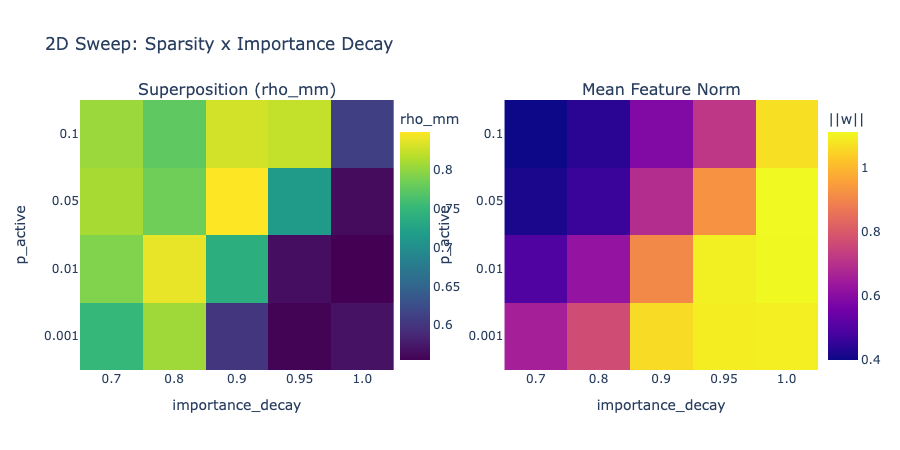

In [12]:
p_labels = [str(v) for v in p_active_2d]
d_labels = [str(v) for v in importance_decays]

fig_phase = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Superposition (rho_mm)", "Mean Feature Norm"],
    horizontal_spacing=0.15,
)

fig_phase.add_trace(
    go.Heatmap(
        z=superposition_map,
        x=d_labels,
        y=p_labels,
        colorscale="Viridis",
        colorbar=dict(title="rho_mm", x=0.42),
    ),
    row=1,
    col=1,
)
fig_phase.add_trace(
    go.Heatmap(
        z=mean_norm_map,
        x=d_labels,
        y=p_labels,
        colorscale="Plasma",
        colorbar=dict(title="||w||", x=1.0),
    ),
    row=1,
    col=2,
)

fig_phase.update_yaxes(title_text="p_active", row=1, col=1)
fig_phase.update_yaxes(title_text="p_active", row=1, col=2)
fig_phase.update_xaxes(title_text="importance_decay", row=1, col=1)
fig_phase.update_xaxes(title_text="importance_decay", row=1, col=2)
fig_phase.update_layout(
    title="2D Sweep: Sparsity x Importance Decay",
    height=450,
    width=900,
)
fig_phase.show()

**Reading the phase diagram:** The top-left corner (high sparsity,
steep importance decay) gives the network the most freedom -- it
can superpose freely and focus capacity on the important features.
The bottom-right (dense, equal importance) is the hardest regime:
all features co-occur often and all matter equally.

---
## Part 4: Grid Slicing

ModelGrid indexing follows NumPy conventions: integer indices
collapse an axis, slices preserve dimensionality. Sub-grids are
views (not copies) into the parent grid.

Slice shape: (4,)


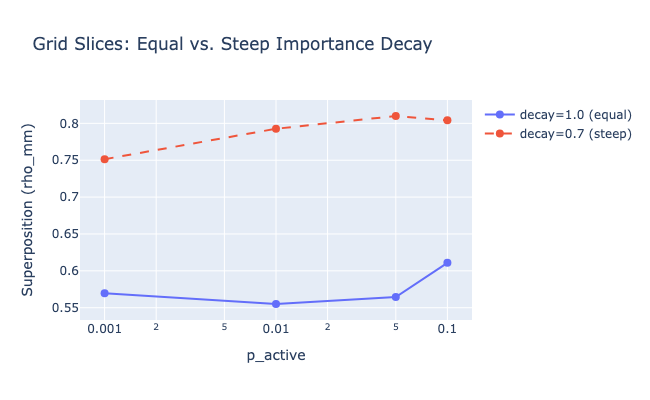

In [13]:
# Fix importance_decay=1.0 (equal importance) to get a 1D slice
# across all p_active values.
equal_importance_slice = grid_2d[:, -1]  # last column: decay=1.0
print(f"Slice shape: {equal_importance_slice.shape}")

# Compare equal vs steep importance at each sparsity level
steep_slice = grid_2d[:, 0]  # first column: decay=0.7

fig_compare = go.Figure()
for label, sub_grid, dash in [
    ("decay=1.0 (equal)", equal_importance_slice, "solid"),
    ("decay=0.7 (steep)", steep_slice, "dash"),
]:
    sup_vals = [sub_grid[i].superposition.item() for i in range(sub_grid.shape[0])]
    fig_compare.add_trace(
        go.Scatter(
            x=p_active_2d,
            y=sup_vals,
            mode="lines+markers",
            name=label,
            line=dict(dash=dash),
            marker=dict(size=8),
        )
    )

fig_compare.update_xaxes(type="log", title_text="p_active")
fig_compare.update_yaxes(title_text="Superposition (rho_mm)")
fig_compare.update_layout(
    title="Grid Slices: Equal vs. Steep Importance Decay",
    height=400,
    width=650,
)
fig_compare.show()

In [14]:
# Verify that slices are views, not copies.
assert equal_importance_slice[0] is grid_2d[0, -1]
print("Confirmed: sub-grid shares model objects with parent grid.")

Confirmed: sub-grid shares model objects with parent grid.


---
## Part 5: Training Dynamics with snapshot_interval

Passing `snapshot_interval` to `fit()` captures model weights at
regular intervals during training. The result is a new ModelGrid
with a `TrainingAxis` (epoch) prepended to the original axes. This
lets you watch superposition emerge over the course of training.

In [15]:
# Train a small 1D grid with snapshots. We use a coarser sweep
# (3 models) and take snapshots every 5000 epochs to keep memory
# manageable.
snapshot_p_values = [0.001, 0.01, 0.1]


def create_snapshot_model(params):
    gen = torch.Generator(DEVICE).manual_seed(SEED)
    return ToyModel(
        distribution=SparseUniform(
            N_FEATURES,
            p_active=params["p_active"],
            device=DEVICE,
            generator=gen,
        ),
        ae=TiedLinearRelu(N_FEATURES, N_HIDDEN, generator=gen, device=DEVICE),
        device=DEVICE,
    )


grid_snap = ModelGrid(
    create_model=create_snapshot_model,
    axes=[Axis("p_active", snapshot_p_values)],
)

# fit() returns a history grid when snapshot_interval is set
history = grid_snap.fit(
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    verbose=True,
    snapshot_interval=5000,
)

print(f"History grid shape: {history.shape}")
print(f"History axes: {history.description}")

  0%|          | 0/25000 [00:00<?, ?epoch/s]

Building history grid:   0%|          | 0/6 [00:00<?, ?epoch/s]

History grid shape: (6, 3)
History axes: {'Epoch': 6, 'p_active': 3}


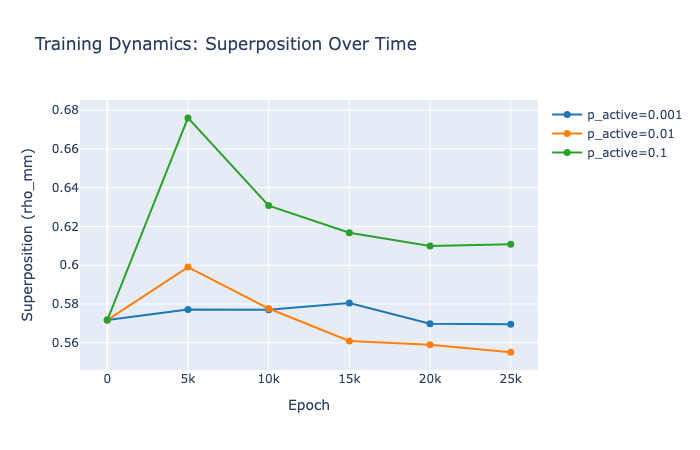

In [16]:
# The first axis is the TrainingAxis (epoch snapshots), the second
# is the original p_active axis. We can index [epoch_idx, model_idx]
# to get any model at any point in training.
epoch_axis = history.axes[0]
epochs = epoch_axis.values

fig_dynamics = go.Figure()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for model_idx, p in enumerate(snapshot_p_values):
    sup_over_time = []
    for epoch_idx in range(len(epochs)):
        model_snapshot = history[epoch_idx, model_idx]
        sup_over_time.append(model_snapshot.superposition.item())
    fig_dynamics.add_trace(
        go.Scatter(
            x=list(epochs),
            y=sup_over_time,
            mode="lines+markers",
            name=f"p_active={p}",
            line=dict(color=colors[model_idx], width=2),
            marker=dict(size=7),
        )
    )

fig_dynamics.update_xaxes(title_text="Epoch")
fig_dynamics.update_yaxes(title_text="Superposition (rho_mm)")
fig_dynamics.update_layout(
    title="Training Dynamics: Superposition Over Time",
    height=450,
    width=700,
)
fig_dynamics.show()

**What to look for:** Superposition typically develops early and
stabilizes. Sparser models (lower p_active) tend to reach higher
superposition sooner because the network has more freedom to
overlap features that rarely co-occur.

## Summary

- **`ModelGrid`** trains all models in a grid simultaneously via
  `torch.vmap`, giving a large speedup over sequential training.
- **`Axis`** defines each sweep dimension with a label and values.
- **`create_model(params)`** is the factory that maps axis values
  to a `ToyModel`. All models must share the same AE architecture.
- **Indexing** follows NumPy conventions: integers collapse axes,
  slices preserve them. Sub-grids are views into the parent.
- **2D grids** enable phase-diagram analysis across two parameters
  (e.g., sparsity x importance decay).
- **`snapshot_interval`** captures training dynamics, returning a
  history grid with an epoch axis prepended.